In [7]:
from src.xs_and_decays import sigma
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("figures.mplstyle")
from scipy.interpolate import interp1d

In [8]:
xs_data = np.loadtxt('data/HNL_xs.txt')
xs_data_interp = interp1d(xs_data[:, 0], xs_data[:, 1], kind='linear', fill_value='extrapolate')

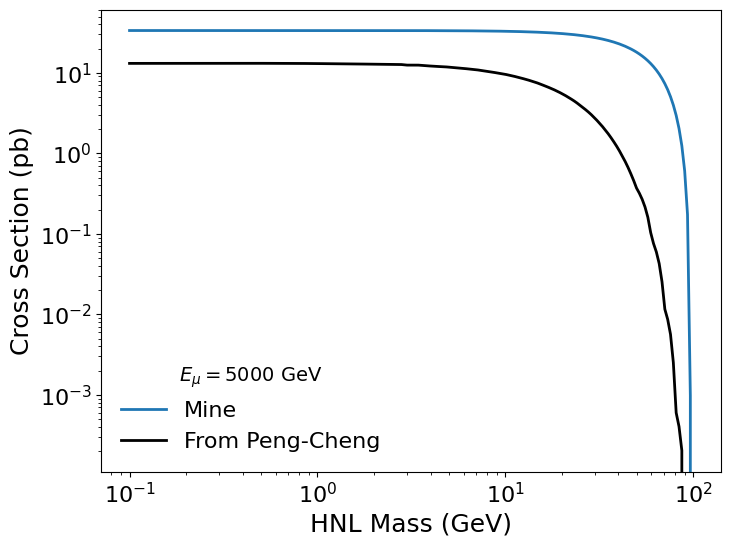

/tmp/ipykernel_2941140/2529848101.py:14: RuntimeWarning: divide by zero encountered in divide
  plt.plot(m_N_range, xs_data_interp(m_N_range) / (sigma(5000, m_N_range, 1)/1e-40), color="black")


(0.0, 1.0)

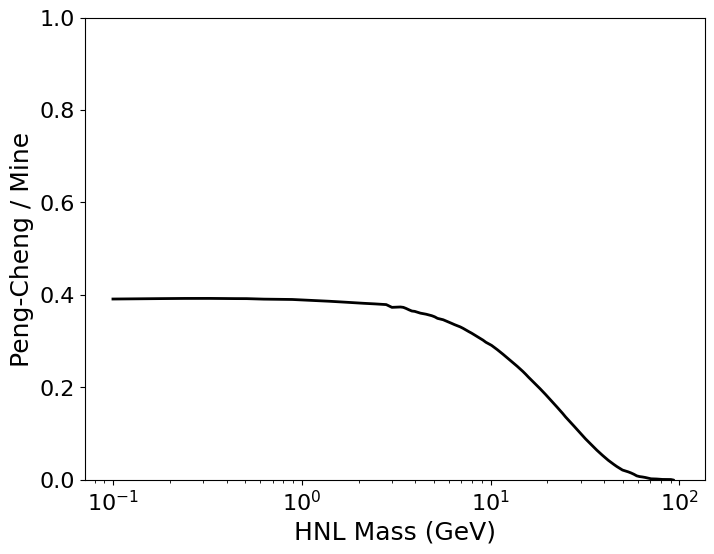

In [11]:
m_N_range = np.logspace(-1, 2, 200)  # HNL mass range from 0.1 to 2 GeV
E_mu_range = [5000]  # Muon energies in GeV
for E_mu in E_mu_range:
    xs = [sigma(E_mu, m_N, 1)/1e-40 for m_N in m_N_range]
    plt.plot(m_N_range, xs, label='Mine')
plt.plot(m_N_range, xs_data_interp(m_N_range), color="black", label='From Peng-Cheng')
plt.xlabel('HNL Mass (GeV)')
plt.ylabel('Cross Section (pb)')
plt.legend(title=r"$E_\mu = %d$ GeV" % E_mu)
plt.loglog()
#plt.ylim(1e-45,1e-38)
plt.show()

plt.plot(m_N_range, xs_data_interp(m_N_range) / (sigma(5000, m_N_range, 1)/1e-40), color="black")
plt.xlabel('HNL Mass (GeV)')
plt.ylabel('Peng-Cheng / Mine')
plt.semilogx()
plt.ylim(0,1)